In [3]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/content/stock_prices.csv')
display(df.head())
print(f"Available stocks: {df['ticker'].unique() if 'ticker' in df.columns else 'N/A'}")

,date,ticker,open,high,low,close,volume,returns_pct
0,2022-01-03,RELIANCE,2476.84,2496.70,2422.91,2459.80,4940428,-1.6079
1,2022-01-04,RELIANCE,2443.34,2497.22,2423.41,2460.31,6310409,0.0207
2,2022-01-05,RELIANCE,2467.38,2481.76,2408.41,2445.09,2920856,-0.6189
3,2022-01-06,RELIANCE,2450.52,2472.16,2399.09,2435.63,2458621,-0.3868
4,2022-01-07,RELIANCE,2415.56,2439.90,2367.79,2403.85,4011166,-1.3049


Available stocks: ['RELIANCE' 'INFOSYS' 'TCS' 'HDFC' 'WIPRO']


```markdown
### Methodology for Time-Series Prediction

#### 1. Window Size Selection
I have chosen a **window size of 30 days**.
*   **Why:** A 30-day window (roughly one month of trading) is sufficient to capture short-term trends and momentum without making the input vector so large that the model struggles with noise or requires excessive parameters. It provides enough historical context for the model to identify patterns like moving averages or recent volatility.

#### 2. Data Splitting Strategy
We must use a **Temporal (Chronological) Split** (e.g., the first 80% of data for training, the next 20% for testing).
*   **Why this is the only acceptable strategy:** Time-series data is inherently ordered. In a real-world scenario, you cannot use information from the future to predict the past. A chronological split ensures the model is evaluated on its ability to forecast unseen future intervals based on historical data, mimicking actual deployment.

#### 3. The Danger of Random Splitting
If a **random split** were used, the reported performance would likely be **artificially inflated** due to **Data Leakage**.
*   **The Result:** Since stock prices are highly correlated with their immediate neighbors (yesterday's price is a great predictor of today's), a random split would place 'Day $n$' in the test set and 'Day $n-1$' and 'Day $n+1$' in the training set. The model would essentially be 'interpolating' between known values rather than 'forecasting' unknown ones. This leads to a model that looks perfect in testing but fails completely in production.
```

In [5]:
# Assuming we pick the first available ticker for the sequence construction
ticker_to_use = df['ticker'].unique()[0] if 'ticker' in df.columns else None
stock_df = df[df['ticker'] == ticker_to_use].copy() if ticker_to_use else df.copy()

# Convert date and sort to ensure chronological order
if 'date' in stock_df.columns:
    stock_df['date'] = pd.to_datetime(stock_df['date'])
    stock_df = stock_df.sort_values('date')

# Define parameters
window_size = 30

# Create sequences
def create_sequences(data, window):
    X, y = [], []
    prices = data['close'].values
    for i in range(len(prices) - window):
        X.append(prices[i:i+window])
        y.append(prices[i+window])
    return np.array(X), np.array(y)

X, y = create_sequences(stock_df, window_size)

# Temporal Split (80% Train, 20% Test)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Prepared data for: {ticker_to_use}")
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Prepared data for: RELIANCE
Train shape: (576, 30), Test shape: (144, 30)


### Task 2: Chat Logs Analysis and Churn EDA
We will now load the chat logs and prepare the data for churn analysis.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
chat_df = pd.read_csv('/content/chat_logs.csv')

# 2. Investigate timestamp parsing
print("Sample timestamps:")
print(chat_df['timestamp'].head())

# Attempting standard parse to see error or format
try:
    pd.to_datetime(chat_df['timestamp'])
    print("\nStandard parsing succeeded.")
except Exception as e:
    print(f"\nStandard parsing failed: {e}")

Sample timestamps:
0       25/05/2024 08:00
1    2024-01-18 00:00:00
2       30/01/2024 19:00
3    2024-11-02 20:00:00
4    2024-12-28 03:00:00
Name: timestamp, dtype: object

Standard parsing failed: time data "2024-01-18 00:00:00" doesn't match format "%d/%m/%Y %H:%M", at position 1. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.


/tmp/ipykernel_9862/3061838765.py:14: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  pd.to_datetime(chat_df['timestamp'])


Columns in chat_df: ['chat_id', 'timestamp', 'duration_min', 'num_turns', 'customer_sentiment', 'primary_intent', 'resolution_status', 'tenure_months', 'product_tier', 'churned_30d']


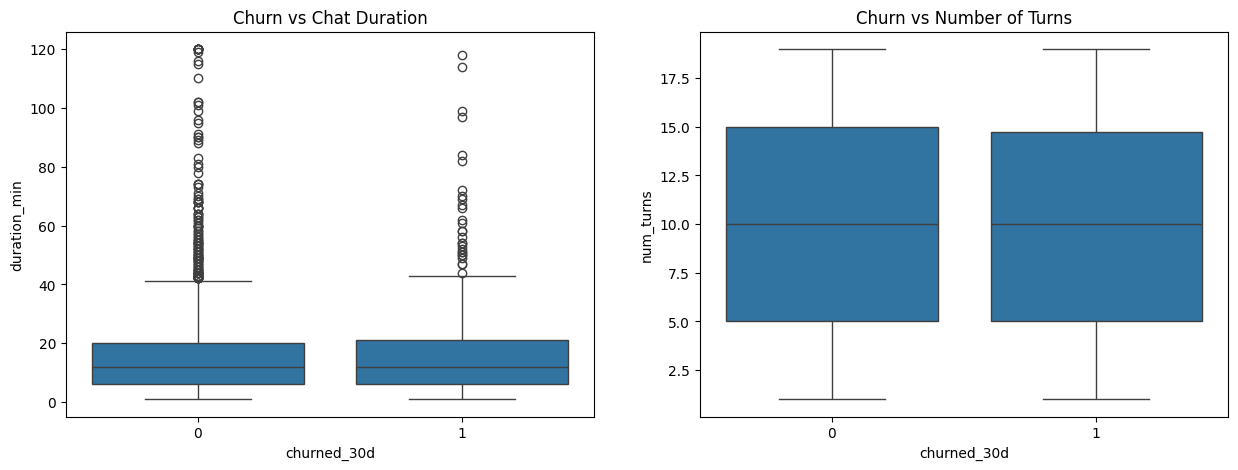

In [11]:
# 3. Fix timestamps and compute churn signal
print("Columns in chat_df:", chat_df.columns.tolist())

# Handling mixed date formats (e.g., DD/MM/YYYY and YYYY-MM-DD)
chat_df['timestamp'] = pd.to_datetime(chat_df['timestamp'], format='mixed', dayfirst=True)

# Map sentiment to numeric for correlation analysis
sentiment_map = {'Very Positive': 2, 'Positive': 1, 'Neutral': 0, 'Negative': -1, 'Very Negative': -2}
chat_df['sentiment_score'] = chat_df['customer_sentiment'].map(sentiment_map)

# Visualization: Churn vs Interaction Metrics
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x='churned_30d', y='duration_min', data=chat_df, ax=axes[0])
axes[0].set_title('Churn vs Chat Duration')

sns.boxplot(x='churned_30d', y='num_turns', data=chat_df, ax=axes[1])
axes[1].set_title('Churn vs Number of Turns')
plt.show()

Corrected Average metrics by churn status:


,duration_min,num_turns,tenure_months,sentiment_score,churned_30d
churned_30d,,,,,
0,16.272727,10.172532,17.967742,-0.465966,0.0
1,16.693833,10.140969,17.123348,-1.574661,1.0


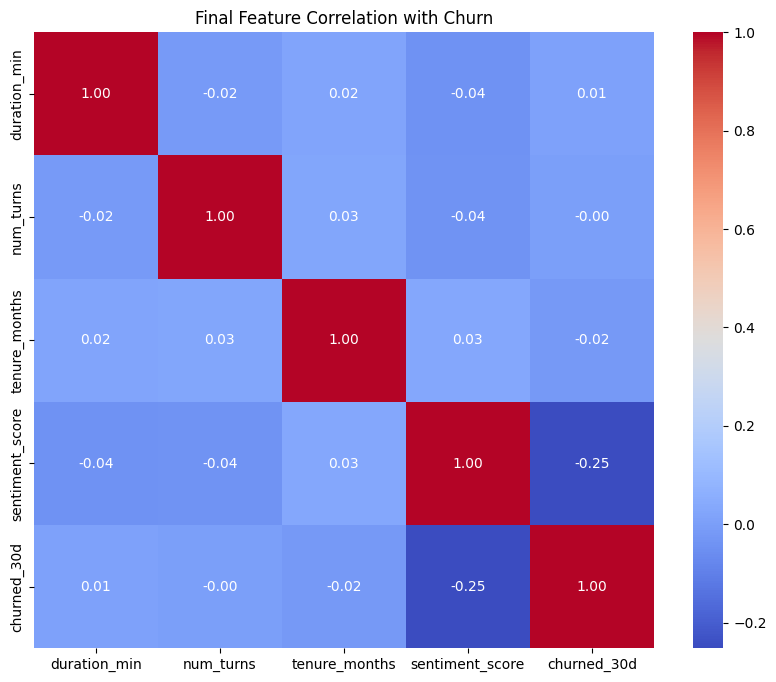

In [14]:
# Define the correct sentiment map based on unique values
correct_sentiment_map = {
    'satisfied': 2,
    'neutral': 0,
    'confused': -1,
    'frustrated': -2,
    'angry': -3
}

# Re-apply mapping
chat_df['sentiment_score'] = chat_df['customer_sentiment'].str.strip().map(correct_sentiment_map)

numeric_cols = ['duration_min', 'num_turns', 'tenure_months', 'sentiment_score', 'churned_30d']

print("Corrected Average metrics by churn status:")
display(chat_df.groupby('churned_30d')[numeric_cols].mean())

# Final correlation check
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(chat_df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Final Feature Correlation with Churn')
plt.show()